# **SUPPLY CHAIN OPTIMIZATION**

**Install Required Libraries**

In [1]:
!pip install xgboost streamlit scikit-learn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.4 MB/s eta 0:00:00


**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

**Uploading Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving supply_chain_data.csv to supply_chain_data (1).csv


**Load and Preprocess Data**

In [9]:
def load_and_clean_data(file):
    df = pd.read_csv('/content/supply_chain_data (1).csv')
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    # Convert date fields if present
    if 'lead_time' in df.columns:
        df['lead_time'] = pd.to_numeric(df['lead_time'], errors='coerce')
    if 'manufacturing_lead_time' in df.columns:
        df['manufacturing_lead_time'] = pd.to_numeric(df['manufacturing_lead_time'], errors='coerce')

    # Fill or drop missing values
    df.dropna(subset=['product_type', 'sku', 'price', 'number_of_products_sold', 'revenue_generated'], inplace=True)
    return df

df = load_and_clean_data('supply_chain_data.csv')
df.head()


,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


**Exploratory Data Analysis (EDA)**

<ipython-input-10-2666708810>:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='product_type', y='revenue_generated', estimator=sum, ci=None)


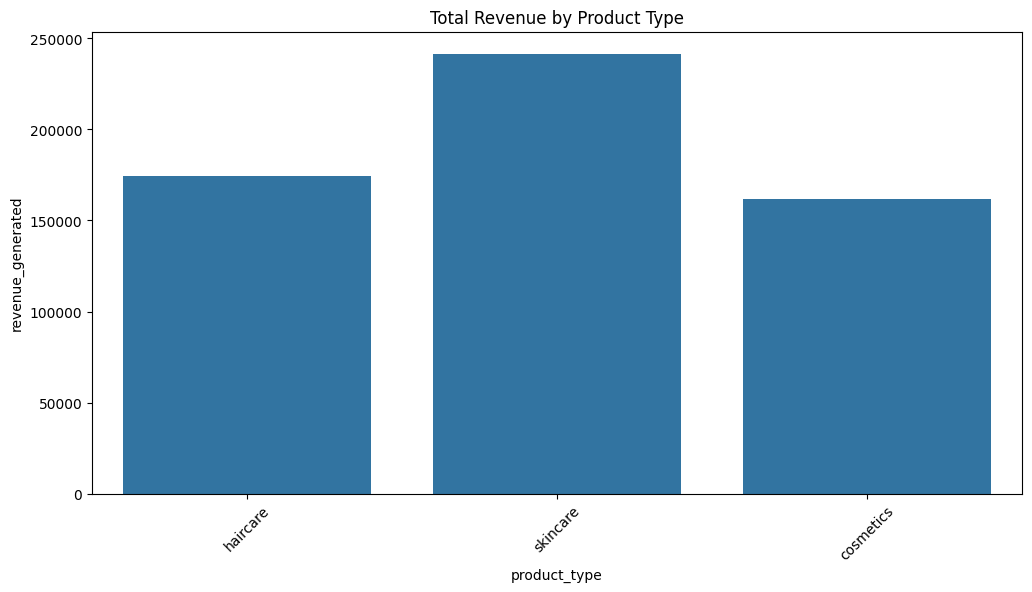

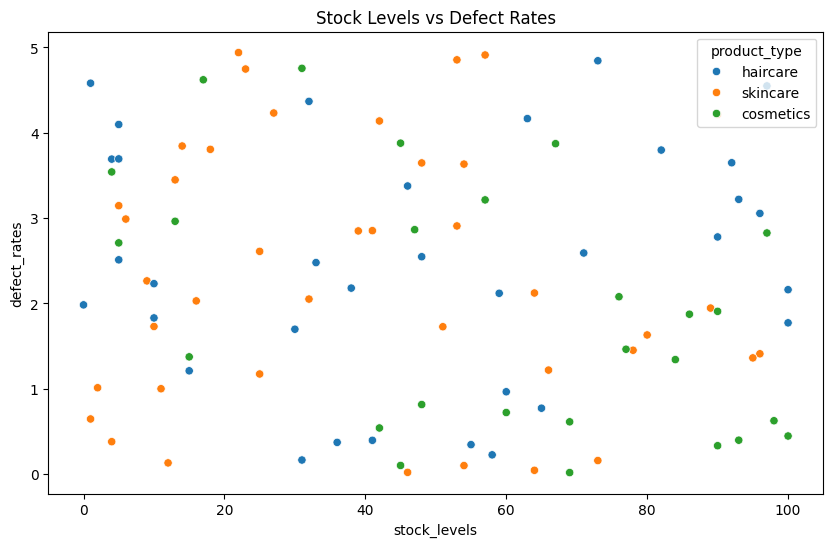

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revenue by product type
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='product_type', y='revenue_generated', estimator=sum, ci=None)
plt.xticks(rotation=45)
plt.title('Total Revenue by Product Type')
plt.show()

# Stock level vs defect rate
plt.figure(figsize=(10,6))
sns.scatterplot(x='stock_levels', y='defect_rates', hue='product_type', data=df)
plt.title('Stock Levels vs Defect Rates')
plt.show()

**Supplier Clustering**

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def supplier_clustering(df):
    # Map inspection results to numeric
    if 'inspection_results' in df.columns:
        df['inspection_score'] = df['inspection_results'].map({
            'Pass': 1,
            'Fail': 0,
            'Pending': 0.5
        })

    # Group by supplier and calculate relevant numeric means
    cluster_df = df.groupby('supplier_name')[[
        'lead_time', 'manufacturing_costs', 'defect_rates', 'inspection_score'
    ]].mean().dropna()

    scaler = StandardScaler()
    scaled = scaler.fit_transform(cluster_df)

    km = KMeans(n_clusters=4, random_state=42)
    cluster_df['cluster'] = km.fit_predict(scaled)

    return cluster_df

supplier_clusters = supplier_clustering(df)
supplier_clusters.head()

,lead_time,manufacturing_costs,defect_rates,inspection_score,cluster
supplier_name,,,,,
Supplier 1,14.777778,45.254027,1.803630,0.629630,2
Supplier 2,18.545455,41.622514,2.362750,0.431818,0
Supplier 3,20.133333,43.634121,2.465786,0.466667,0
Supplier 4,15.222222,62.709727,2.337397,0.166667,1
Supplier 5,18.055556,44.768243,2.665408,0.388889,3


from matplotlib import pyplot as plt
_df_0['lead_time'].plot(kind='hist', bins=20, title='lead_time')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['manufacturing_costs'].plot(kind='hist', bins=20, title='manufacturing_costs')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['defect_rates'].plot(kind='hist', bins=20, title='defect_rates')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['inspection_score'].plot(kind='hist', bins=20, title='inspection_score')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['lead_time']
  ys = series['cluster']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('lead_time', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('lead_time')
_ = plt.ylabel('cluster')

from matplotlib import pyplot as plt
_df_12['lead_time'].plot(kind='line', figsize=(8, 4), title='lead_time')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['manufacturing_costs'].plot(kind='line', figsize=(8, 4), title='manufacturing_costs')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['defect_rates'].plot(kind='line', figsize=(8, 4), title='defect_rates')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['inspection_score'].plot(kind='line', figsize=(8, 4), title='inspection_score')
plt.gca().spines[['top', 'right']].set_visible(False)

**Demand Forecasting Using XGBoost**

In [14]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

def forecast_demand(df):
    features = df[['price', 'stock_levels', 'manufacturing_costs']].copy()
    target = df['number_of_products_sold']

    features = features.dropna()
    target = target[features.index]

    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

    model = XGBRegressor()
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"Demand Forecasting Accuracy (R²): {score*100:.2f}%")
    return model

demand_model = forecast_demand(df)

Demand Forecasting Accuracy (R²): -44.46%


**EOQ & Reorder Point Calculation**

In [16]:
import numpy as np

def calculate_eoq(demand_rate, ordering_cost, holding_cost):
    return np.sqrt((2 * demand_rate * ordering_cost) / holding_cost)

def reorder_point(daily_demand, lead_time):
    return daily_demand * lead_time

# Use values from dataset if available, else defaults
annual_demand = df['number_of_products_sold'].sum()
ordering_cost = df['shipping_costs'].mean() if 'shipping_costs' in df else 50
holding_cost = df['price'].mean() * 0.1

eoq = calculate_eoq(annual_demand, ordering_cost, holding_cost)
rop = reorder_point(daily_demand=annual_demand/365, lead_time=7)

print("EOQ:", round(eoq, 2))
print("Reorder Point:", round(rop, 2))

EOQ: 321.59
Reorder Point: 884.09
EOQ: 321.59
Reorder Point: 884.09


**Lead Time Analysis**

In [17]:
def lead_time_by_supplier(df):
    return df.groupby('supplier_name')['lead_time'].mean().sort_values()

lead_time_summary = lead_time_by_supplier(df)
lead_time_summary.head()

,lead_time
supplier_name,
Supplier 1,14.777778
Supplier 4,15.222222
Supplier 5,18.055556
Supplier 2,18.545455
Supplier 3,20.133333


**Summary of Results**

In [18]:
print("Top 5 Fastest Suppliers (by average lead time):")
print(lead_time_summary.head())

print("\nSupplier Clusters Distribution:")
print(supplier_clusters['cluster'].value_counts())

Top 5 Fastest Suppliers (by average lead time):
supplier_name
Supplier 1    14.777778
Supplier 4    15.222222
Supplier 5    18.055556
Supplier 2    18.545455
Supplier 3    20.133333
Name: lead_time, dtype: float64

Supplier Clusters Distribution:
cluster
0    2
2    1
1    1
3    1
Name: count, dtype: int64
